## 1. Data Description and Distribution

The dataset contains measurements from microalgae cultivation experiments, including environmental and physicochemical variables such as irradiance, temperature, pH, nitrate concentration (NO₃), dissolved oxygen (OD), oxygen gas (O₂), carbon dioxide (CO₂), and conductivity, alongside biomass measurements obtained through the dry weight method.

It is important to note that the distribution of the target variable (biomass) does not follow a normal distribution. This is expected given the nature of the data collection process. Biomass measurements were taken every 48 hours, while sensor data were recorded at 15-minute intervals and later temporally aligned using interpolation methods. As a result, the dataset reflects a dynamic biological process rather than independent and identically distributed observations. The variability observed in biomass is therefore likely driven by temporal growth dynamics and experimental conditions, rather than random sampling from a stationary population. Consequently, assuming normality in the target variable is not appropriate in this context.

---


## 2. Exploratory Data Analysis

### 2.1. Packages

In [11]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2.2.  Dataset

In [12]:
# 2. Load data
df = pd.read_csv("Verrucodesmus_verrucosus.csv")


### 2.3. Basic information

In [13]:
df.shape

(1080, 9)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Irradiance    1080 non-null   float64
 1   NO3           1080 non-null   float64
 2   Temperature   1080 non-null   float64
 3   pH            1080 non-null   float64
 4   Biomass       1080 non-null   float64
 5   O2 Gas        1080 non-null   float64
 6   CO2 Gas       1080 non-null   float64
 7   OD            1080 non-null   float64
 8   Conductivity  1080 non-null   float64
dtypes: float64(9)
memory usage: 76.1 KB


### 2.4. Descriptive Analysis

In [15]:
df.describe()

,Irradiance,NO3,Temperature,pH,Biomass,O2 Gas,CO2 Gas,OD,Conductivity
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,141.415760,93.384793,22.365758,7.697505,1.670003,9.382823,642.131944,7.377916,280.089850
std,31.088741,62.123711,0.949002,0.826699,0.879431,0.119489,144.493013,0.600034,13.526595
min,79.730000,23.251849,20.921888,6.555274,0.115000,9.212269,406.400000,6.345674,253.101780
25%,113.921448,40.971369,21.498363,6.955217,0.881500,9.277005,529.100000,6.700042,270.956347
50%,141.368136,74.009351,22.235716,7.843361,1.908000,9.350141,646.800000,7.560494,280.054057
75%,166.756556,134.319122,23.305544,7.923252,2.438250,9.519147,746.900000,7.929946,292.119173
max,195.400000,244.542156,23.892744,9.515302,3.333000,9.584377,897.200000,8.019339,307.241921


### 2.5. Biomass data distribution

Text(0.5, 1.0, 'Biomass distribution')

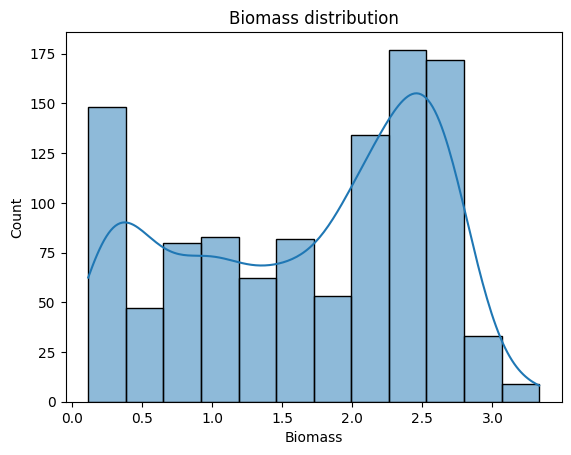

In [16]:
# 4. Target distribution
sns.histplot(df["Biomass"], kde=True)
plt.title("Biomass distribution")


Exploratory analysis revealed that biomass exhibits a non-normal and potentially multimodal distribution, suggesting the presence of different growth phases or regimes within the cultivation process. This reinforces the idea that the system behaves dynamically over time.

### 2.6. Correlations

<Axes: >

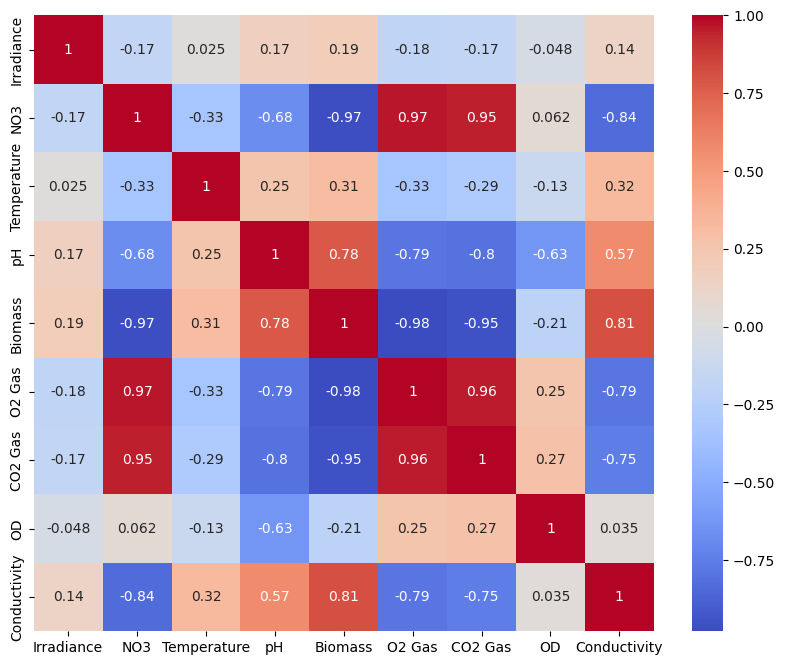

In [17]:
# 5. Correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

Correlation analysis identified several key relationships between biomass and the measured variables. Biomass shows strong positive correlations with pH (r ≈ 0.78) and conductivity (r ≈ 0.81), indicating that these variables may act as important drivers or proxies of growth conditions. Temperature shows a moderate positive relationship (r ≈ 0.31), while irradiance appears to have a weaker linear association (r ≈ 0.19), suggesting potential non-linear effects.

In contrast, very strong negative correlations were observed between biomass and NO₃ (r ≈ -0.97), O₂ gas (r ≈ -0.98), and CO₂ gas (r ≈ -0.95). From a biological perspective, these relationships are consistent with nutrient consumption and metabolic activity: as biomass increases, nitrate levels decrease due to uptake, and gas concentrations change as a result of photosynthetic and respiratory processes.

### 2.7 Exploratory Analysis: Relationship Between Predictors and Biomass

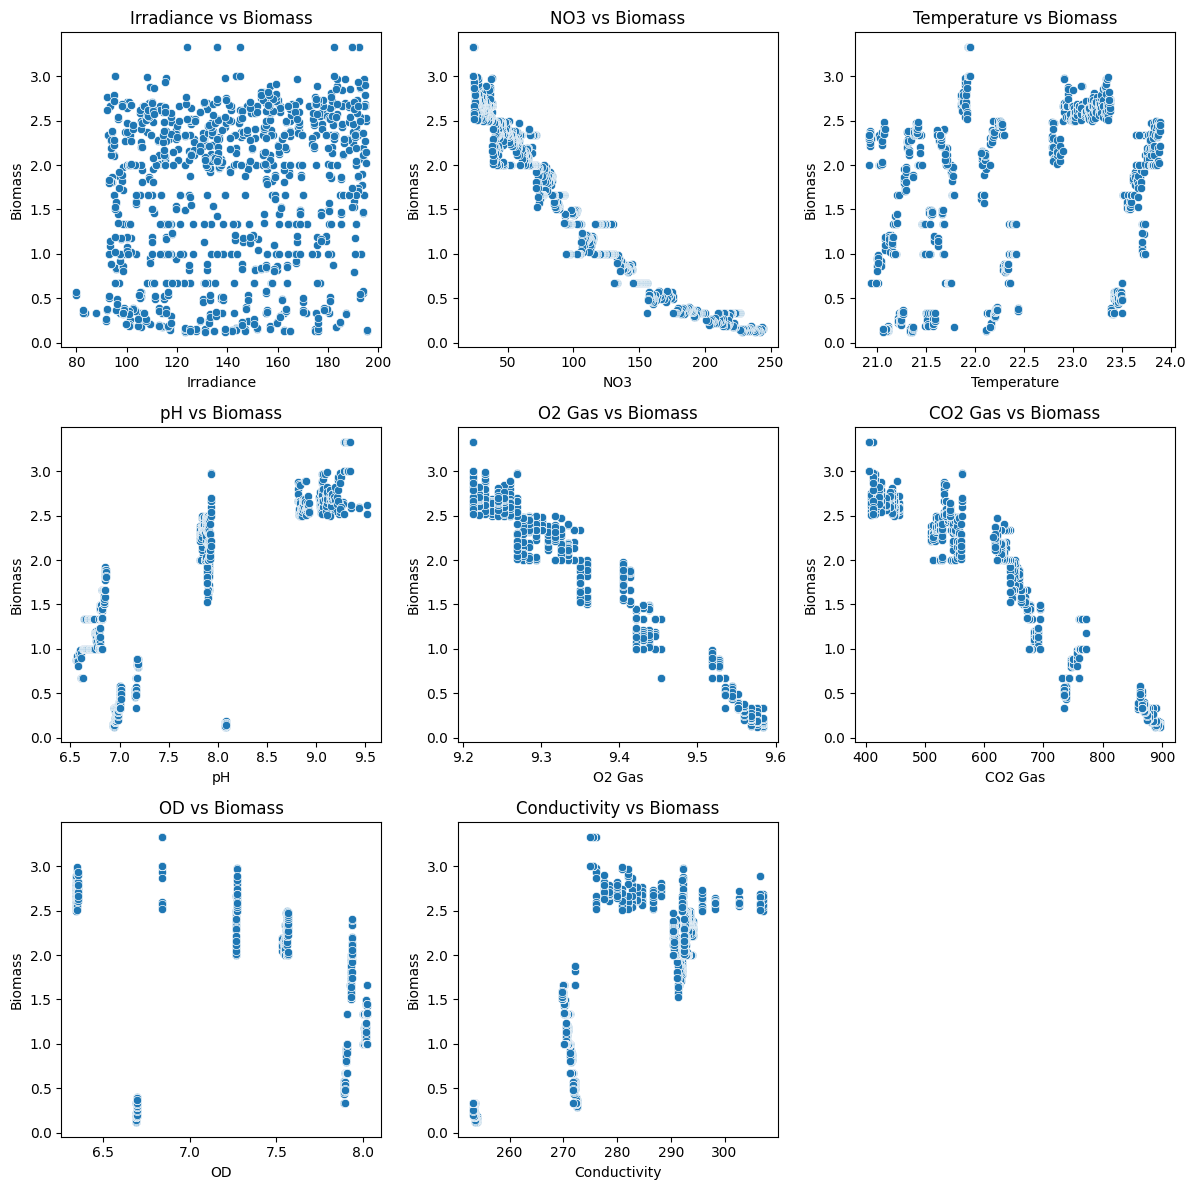

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [col for col in df.columns if col != "Biomass"]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
axes = axes.flatten()  # facilita iteración

for i, col in enumerate(features):
    sns.scatterplot(x=df[col], y=df["Biomass"], ax=axes[i])
    axes[i].set_title(f"{col} vs Biomass")

# eliminar ejes vacíos si hay menos de 8 variables
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---

###  3 Biological Interpretation

These patterns indicate that the dataset captures the dynamics of a biological growth system rather than static environmental conditions. The strong inverse relationships between biomass and key nutrients or gases suggest that the model is effectively observing resource consumption and metabolic shifts over time. This reinforces the need to interpret the data within a process-driven framework, where variables are interdependent and evolve together during cultivation.

---

###  4. Key Insight

Biomass production is primarily driven by nutrient availability and metabolic dynamics, with nitrate (NO₃) emerging as the dominant factor through its strong inverse relationship with biomass, reflecting active nutrient consumption during growth. This behavior, together with the strong correlations observed with gas variables and the non-normal, potentially multimodal distribution of biomass, indicates that the dataset captures distinct growth phases within a dynamic cultivation process. Rather than representing independent observations, the data reflect an evolving biological system in which environmental conditions and internal states are tightly coupled. Consequently, biomass variability is best understood as the outcome of interacting processes—nutrient depletion, metabolic activity, and changing culture conditions—reinforcing the need for modeling approaches capable of capturing non-linear and interdependent relationships.

---